In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
trump_posts = pd.read_csv("realdonaldtrump-truthsocial-20221101-present.tsv", sep="\t", engine="python", on_bad_lines="skip")
trump_posts.head()

,id,username,date,reblog_flag,quote_flag,replies_count,reblogs_count,favourites_count,content,content_html,...,notes,deleted_flag,deleted_date,readability_flag,sentiment_flag,index_flag,entity_flag,auto_id,created,modified
0,109267074253249728,realDonaldTrump,2022-11-01 02:13:57,1.0,NaN,651.0,5242.0,23119.0,RT @PatriotsInControl,"<p>RT <span class=""h-card""><a href=""https://tr...",...,NaN,NaN,NaN,1.0,1.0,1,1.0,525837,2022-11-01 02:14:02,2026-02-22 07:10:11
1,109269853202681557,realDonaldTrump,2022-11-01 14:00:40,NaN,NaN,862.0,5423.0,12126.0,Here we go again! Rigged Election! https:// ju...,<p>Here we go again! Rigged Election! <a href=...,...,NaN,NaN,NaN,1.0,1.0,1,1.0,525839,2022-11-01 14:01:02,2026-02-22 07:10:11
2,109269869277798724,realDonaldTrump,2022-11-01 14:04:46,NaN,NaN,749.0,6304.0,14987.0,We really are living in a Communist Country. W...,<p>We really are living in a Communist Country...,...,NaN,NaN,NaN,1.0,1.0,1,1.0,525841,2022-11-01 14:05:01,2026-02-22 07:10:11
3,109269872730277773,realDonaldTrump,2022-11-01 14:05:38,NaN,NaN,137.0,2461.0,10388.0,https://www. texastribune.org/2022/10/22/do na...,"<p><a href=""https://www.texastribune.org/2022/...",...,NaN,NaN,NaN,1.0,1.0,1,1.0,525843,2022-11-01 14:06:02,2026-02-22 07:10:11
4,109269871636367797,realDonaldTrump,2022-11-01 14:05:22,NaN,NaN,130.0,2524.0,8963.0,https://www. rsbnetwork.com/news/venezuela- on...,"<p><a href=""https://www.rsbnetwork.com/news/ve...",...,NaN,NaN,NaN,1.0,1.0,1,1.0,525844,2022-11-01 14:06:02,2026-02-22 07:10:11


In [5]:
trump_posts.shape

(30309, 56)

In [6]:
#filters for posts just related to tariffs
tariff_posts = trump_posts[trump_posts["content"].str.contains(r"\btariffs?\b", case=False, na=False)]
tariff_posts.shape

(357, 56)

In [7]:
#convert tariff post timestamps to look at separate date and hour
tariff_posts = trump_posts[
    trump_posts["content"].str.contains("tariff", case=False, na=False)
].copy()

tariff_posts["date"] = pd.to_datetime(tariff_posts["date"])
tariff_posts["post_date"] = tariff_posts["date"].dt.date
tariff_posts["post_hour"] = tariff_posts["date"].dt.hour
#determine if post was made after market close
tariff_posts["after_close"] = tariff_posts["post_hour"] >= 16

In [8]:
#assign trading day
tariff_posts["event_day"] = tariff_posts["date"].dt.date
tariff_posts.loc[tariff_posts["after_close"], "event_day"] += pd.Timedelta(days=1)

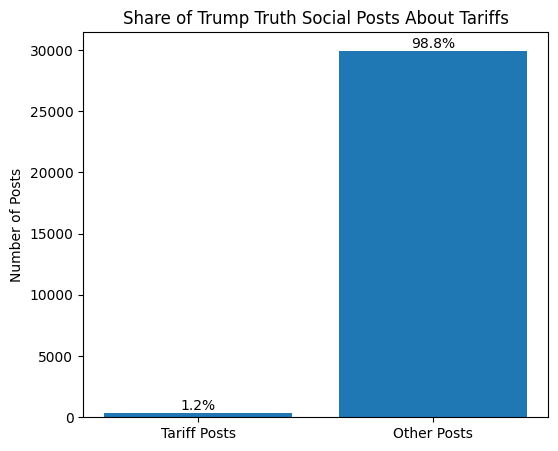

In [9]:
#look at how many of Trump's Truth Social posts are about tariffs

labels = ["Tariff Posts", "Other Posts"]
values = [len(tariff_posts), len(trump_posts) - len(tariff_posts)]

total = sum(values)
percentages = [(v / total) * 100 for v in values]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, values, color=["#1f77b4"])

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{percentages[i]:.1f}%",
             ha='center',
             va='bottom')

plt.title("Share of Trump Truth Social Posts About Tariffs")
plt.ylabel("Number of Posts")

plt.show()

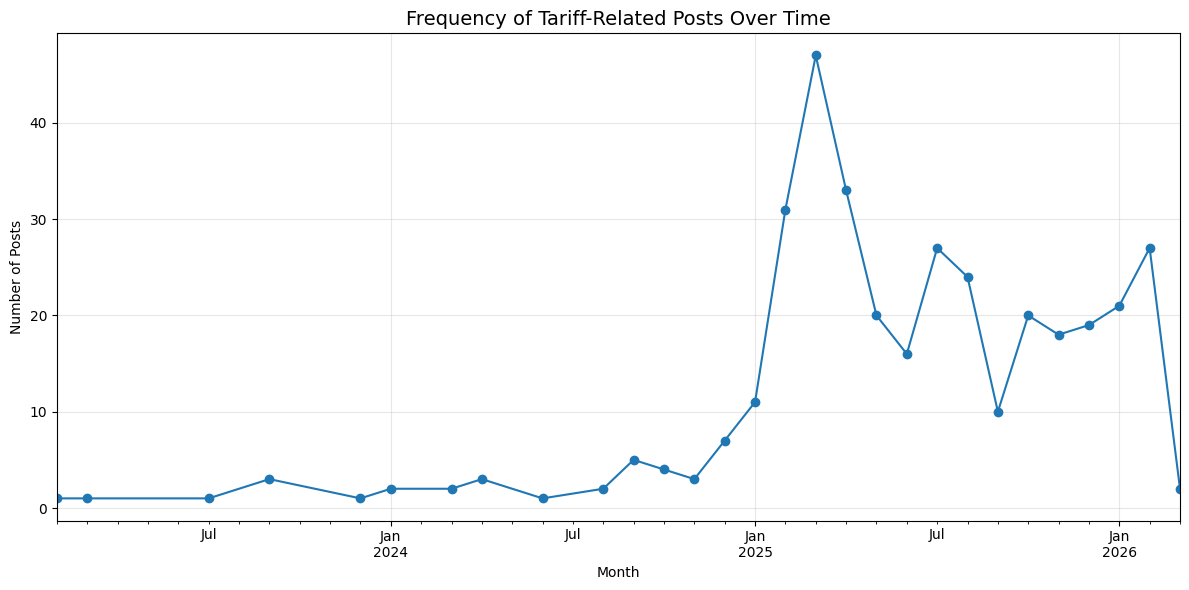

In [10]:
#look at frequency of tariff-related posts, are there particular high months?

tariff_posts["month"] = tariff_posts["date"].dt.to_period("M")
monthly_posts = tariff_posts.groupby("month").size()

plt.figure(figsize=(12,6))
monthly_posts.plot(marker="o")

plt.title("Frequency of Tariff-Related Posts Over Time", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Posts")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Yahoo finance data 

In [11]:
import yfinance as yf
sp500 = yf.download("^GSPC", start="2022-11-01")
sp500.columns = sp500.columns.droplevel(1)
sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2022-11-01,3856.100098,3911.790039,3843.800049,3901.790039,4481210000
2022-11-02,3759.689941,3894.439941,3758.679932,3852.899902,4899000000
2022-11-03,3719.889893,3750.590088,3698.149902,3733.250000,4625290000
2022-11-04,3770.550049,3796.340088,3708.840088,3766.979980,5400180000
2022-11-07,3806.800049,3813.949951,3764.699951,3780.709961,4341620000


In [12]:
#calculate the daily returns
sp500["return"] = sp500["Close"].pct_change()
sp500.head()

Price,Close,High,Low,Open,Volume,return
Date,,,,,,
2022-11-01,3856.100098,3911.790039,3843.800049,3901.790039,4481210000,NaN
2022-11-02,3759.689941,3894.439941,3758.679932,3852.899902,4899000000,-0.025002
2022-11-03,3719.889893,3750.590088,3698.149902,3733.250000,4625290000,-0.010586
2022-11-04,3770.550049,3796.340088,3708.840088,3766.979980,5400180000,0.013619
2022-11-07,3806.800049,3813.949951,3764.699951,3780.709961,4341620000,0.009614


In [13]:
# Estimate daily variance using the Garman–Klass estimator
sp500["variance"] = (0.5 * (np.log(sp500['High'] / sp500['Low'])**2) - (2*np.log(2) - 1) * (np.log(sp500['Close'] / sp500['Open'])**2))
sp500.head()

Price,Close,High,Low,Open,Volume,return,variance
Date,,,,,,,
2022-11-01,3856.100098,3911.790039,3843.800049,3901.790039,4481210000,NaN,0.000100
2022-11-02,3759.689941,3894.439941,3758.679932,3852.899902,4899000000,-0.025002,0.000398
2022-11-03,3719.889893,3750.590088,3698.149902,3733.250000,4625290000,-0.010586,0.000094
2022-11-04,3770.550049,3796.340088,3708.840088,3766.979980,5400180000,0.013619,0.000272
2022-11-07,3806.800049,3813.949951,3764.699951,3780.709961,4341620000,0.009614,0.000066


In [14]:
sp500 = sp500.reset_index()
sp500["Date"] = pd.to_datetime(sp500["Date"]).dt.date
print(sp500["Date"].min(), sp500["Date"].max())
print(tariff_posts["event_day"].min(), tariff_posts["event_day"].max())

2022-11-01 2026-05-05
2023-02-18 2026-03-06


In [15]:
tariff_days = tariff_posts["event_day"].unique()
sp500["tariff_day"] = sp500["Date"].isin(tariff_days)
sp500.groupby("tariff_day")["return"].mean()

tariff_day
False    0.000999
True    -0.000293
Name: return, dtype: float64

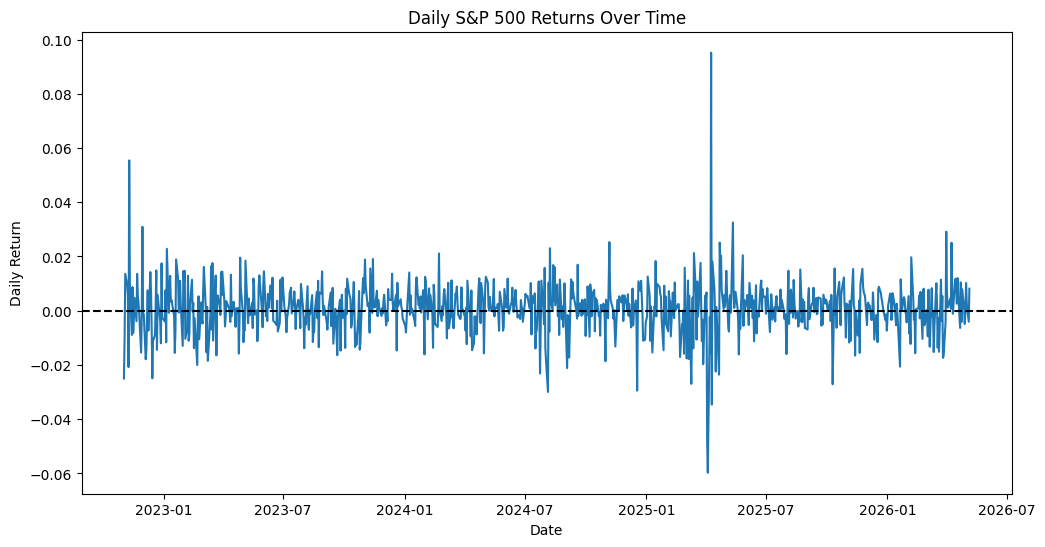

In [16]:
#look at the daily s&p returns

plt.figure(figsize=(12,6))

plt.plot(sp500["Date"], sp500["return"])

plt.title("Daily S&P 500 Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.axhline(0, linestyle="--", color="black")
plt.show()

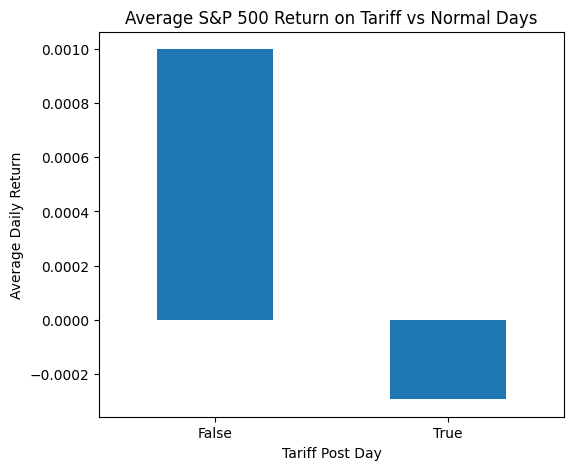

In [17]:
mean_returns = sp500.groupby("tariff_day")["return"].mean()

plt.figure(figsize=(6,5))
mean_returns.plot(kind="bar")

plt.title("Average S&P 500 Return on Tariff vs Normal Days")
plt.xlabel("Tariff Post Day")
plt.ylabel("Average Daily Return")

plt.xticks(rotation=0)
plt.show()

In [18]:
sp500[sp500["tariff_day"] == False]


Price,Date,Close,High,Low,Open,Volume,return,variance,tariff_day
0,2022-11-01,3856.100098,3911.790039,3843.800049,3901.790039,4481210000,NaN,0.000100,False
1,2022-11-02,3759.689941,3894.439941,3758.679932,3852.899902,4899000000,-0.025002,0.000398,False
2,2022-11-03,3719.889893,3750.590088,3698.149902,3733.250000,4625290000,-0.010586,0.000094,False
3,2022-11-04,3770.550049,3796.340088,3708.840088,3766.979980,5400180000,0.013619,0.000272,False
4,2022-11-07,3806.800049,3813.949951,3764.699951,3780.709961,4341620000,0.009614,0.000066,False
...,...,...,...,...,...,...,...,...,...
874,2026-04-29,7135.950195,7145.629883,7107.859863,7131.609863,5123100000,-0.000399,0.000014,False
875,2026-04-30,7209.009766,7219.830078,7126.149902,7161.750000,5723790000,0.010238,0.000069,False
876,2026-05-01,7230.120117,7272.520020,7229.319824,7234.540039,4847390000,0.002928,0.000018,False
877,2026-05-04,7200.750000,7244.540039,7174.120117,7228.379883,5215480000,-0.004062,0.000042,False


(array([404., 170.,  70.,  35.,  11.,   9.,   4.,   8.,   3.,   4.,   1.,
          1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([1.13051701e-06, 3.22220798e-05, 6.33136425e-05, 9.44052053e-05,
        1.25496768e-04, 1.56588331e-04, 1.87679894e-04, 2.18771456e-04,
        2.49863019e-04, 2.80954582e-04, 3.12046145e-04, 3.43137707e-04,
        3.74229270e-04, 4.05320833e-04, 4.36412396e-04, 4.67503959e-04,
        4.98595521e-04, 5.29687084e-04, 5.60778647e-04, 5.91870210e-04,
        6.22961772e-04, 6.54053335e-04, 6.85144898e-04, 7.16236461e-04,
        7.47328023e-04, 7.78419586e-04, 8.09511149e-04, 8.40602712e-04,
        8.71694274e-04, 9.02785837e-04, 9.33877400e-04]),
 <BarContainer object of 30 artists>)

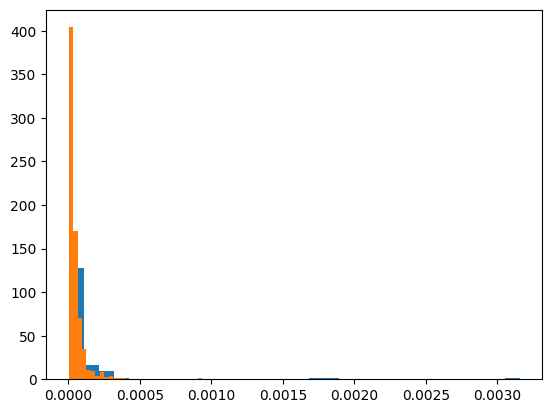

In [19]:
plt.hist(sp500[sp500["tariff_day"] == True]["variance"], bins = 30)
plt.hist(sp500[sp500["tariff_day"] == False]["variance"], bins = 30)


#### T test

In [20]:
from scipy.stats import ttest_ind

# Split into two groups
var_true = sp500.loc[sp500['tariff_day'] == True, 'variance']
var_false = sp500.loc[sp500['tariff_day'] == False, 'variance']

# Welch's t-test (recommended when variances differ)
t_stat, p_val = ttest_ind(var_true, var_false, equal_var=False, alternative = "greater")

print("t-statistic:", t_stat)
print("p-value:", p_val)

t-statistic: 2.1671678262092273
p-value: 0.015857645230412287


In [21]:
print(sp500[sp500["tariff_day"] == True]["variance"].mean())
print(sp500[sp500["tariff_day"] == False]["variance"].mean())

0.00010208191853775828
4.6363414814573997e-05


Days on which Trump posted about tariffs on Truth Social are associated with statistically significantly higher S&P 500 volatility compared to other days (t = 2.17, p = 0.016), using the Garman-Klass variance estimator and a one-sided Welch's t-test. The magnitude is notable, average variance on tariff days (0.000102) is roughly 2.2x higher than on non-tariff days (0.0000464). That said, reverse causality remains the key limitation, Trump may be reacting to market turbulence rather than driving it. Future work with intraday data and a formal event-study design would help determine whether this relationship is causal, reactive, or coincidental.